<a href="https://colab.research.google.com/github/Dipto1971/Statistical-Analysis-Data-Science/blob/main/Assignment/Assignment(2022_2_60_044).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Github: https://github.com/Dipto1971/Statistical-Analysis-Data-Science/tree/main/Assignment

# Loading a DataFrame from a Dataset

In [12]:
!gdown --id 1XnxWbFgcwFmbNY4mQAiTaMqL-aB8YGbl
url = 'education_data.csv'
df = pd.read_csv(url)
df.head()

/usr/local/lib/python3.10/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1XnxWbFgcwFmbNY4mQAiTaMqL-aB8YGbl
To: /content/education_data.csv
100% 883k/883k [00:00<00:00, 10.1MB/s]


,Student_ID,Age,Gender,Department,Year_of_Study,CGPA,Attendance_Percentage,Study_Hours_per_Week,Extracurricular_Activities,Part_Time_Job,Satisfaction_Level,Scholarship,Parental_Education_Level,Internet_Access,Family_Income
0,S0001,24,Non-binary,Biology,Second,3.78,86.13,28,Yes,Yes,Neutral,Yes,PhD,Yes,Low
1,S0002,21,Non-binary,Physics,Third,2.69,57.24,11,No,No,Very Satisfied,No,PhD,No,Medium
2,S0003,28,Male,Economics,Third,2.85,71.93,19,Yes,Yes,Very Dissatisfied,No,Bachelor's,No,Medium
3,S0004,25,Male,Chemistry,Fourth,2.91,77.15,29,Yes,No,Very Satisfied,No,Bachelor's,No,Medium
4,S0005,22,Female,Biology,Fourth,2.35,85.11,21,Yes,No,Dissatisfied,Yes,High School,No,High


# Data Cleaning and Analysis

In [13]:
# Check for Missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
print("Missing Data: ", missing_percentage)

# Theree's missing data in CGPA and Attendance_Percentage

Missing Data:  Student_ID                     0.00
Age                            0.00
Gender                         0.00
Department                     0.00
Year_of_Study                  0.00
CGPA                          10.01
Attendance_Percentage         10.24
Study_Hours_per_Week           0.00
Extracurricular_Activities     0.00
Part_Time_Job                  0.00
Satisfaction_Level             0.00
Scholarship                    0.00
Parental_Education_Level       0.00
Internet_Access                0.00
Family_Income                  0.00
dtype: float64


##Visualizing the missing Data

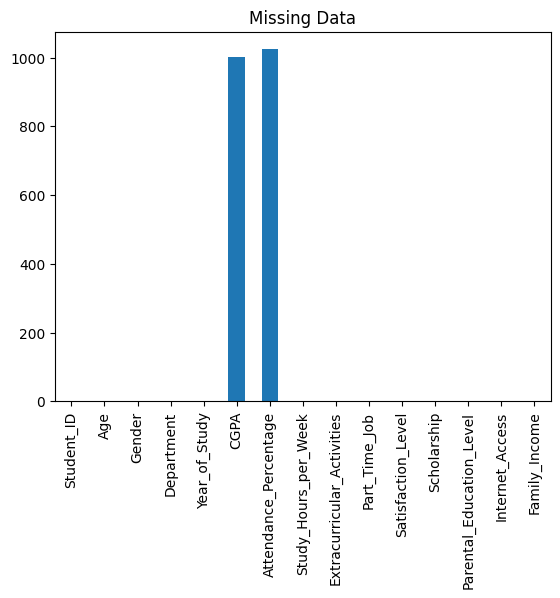

Mean of CGPA:  3.000502278030892
Mean of Attendance Percentage:  75.1243404634581


In [14]:
# Visualize Missing data using historgram
missing_data.plot(kind='bar', title='Missing Data')
plt.show()

# Missing data in columns CGPA and Attendance Percentage. Determining the CGPA_mean and Attendance_Percentage_mean
CGPA_mean = df['CGPA'].mean()
Attendance_Percentage_mean = df['Attendance_Percentage'].mean()
print("Mean of CGPA: ", CGPA_mean)
print("Mean of Attendance Percentage: ", Attendance_Percentage_mean)

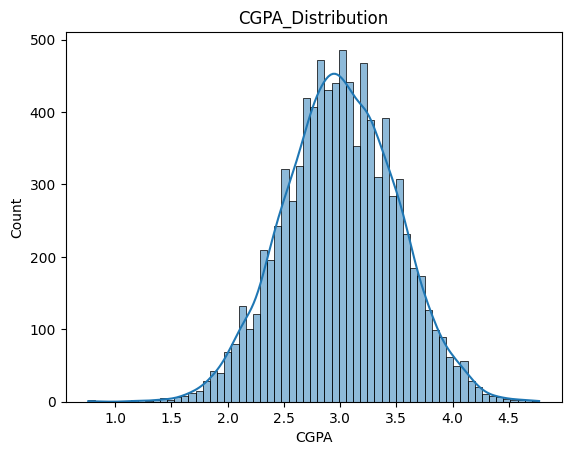

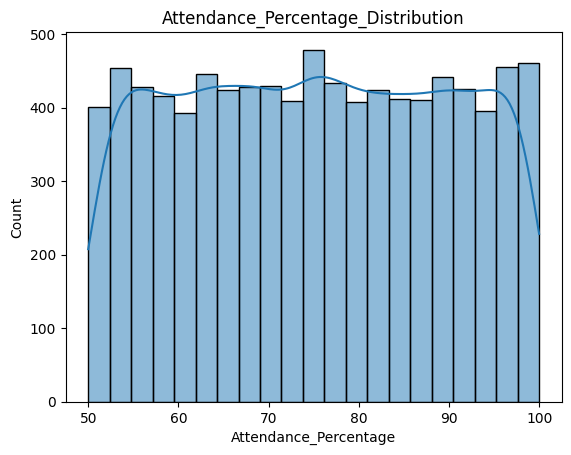

In [15]:
# Checking if CGPA data is normally distributed
sns.histplot(df['CGPA'], kde=True)
plt.title('CGPA_Distribution')
plt.show()

# Checking if Attendance_Percentage data is normally distributed
sns.histplot(df['Attendance_Percentage'], kde=True)
plt.title('Attendance_Percentage_Distribution')
plt.show()

###Handling missing Data (Replacing missing values of CGPA and Attendance Percentage Column with Mean)

In [16]:
# Normally distributed, so replacing with Mean
# Handling missing data: For only CGPA and Attendance_Percentage columns
df['CGPA'].fillna(df['CGPA'].mean(), inplace=True)
df['Attendance_Percentage'].fillna(df['Attendance_Percentage'].mean(), inplace=True)


<ipython-input-16-d3e089a4b348>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CGPA'].fillna(df['CGPA'].mean(), inplace=True)
<ipython-input-16-d3e089a4b348>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

##Confirming that there's no missing data in any column

In [17]:
# Check for missing data after cleaning
missing_data_after = df.isnull().sum()
missing_percentage_after = (missing_data_after / len(df)) * 100
print("Missing Data After Cleaning:\n", missing_percentage_after)

# Show CGPA counts according to range
df['CGPA'].value_counts(bins=5).sort_index()

# There's CGPA values above 4

Missing Data After Cleaning:
 Student_ID                    0.0
Age                           0.0
Gender                        0.0
Department                    0.0
Year_of_Study                 0.0
CGPA                          0.0
Attendance_Percentage         0.0
Study_Hours_per_Week          0.0
Extracurricular_Activities    0.0
Part_Time_Job                 0.0
Satisfaction_Level            0.0
Scholarship                   0.0
Parental_Education_Level      0.0
Internet_Access               0.0
Family_Income                 0.0
dtype: float64


,count
"(0.755, 1.562]",17
"(1.562, 2.364]",892
"(2.364, 3.166]",5723
"(3.166, 3.968]",3136
"(3.968, 4.77]",232


# Outlier Detection

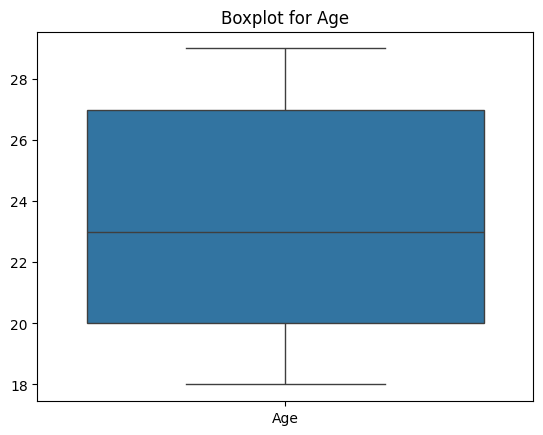

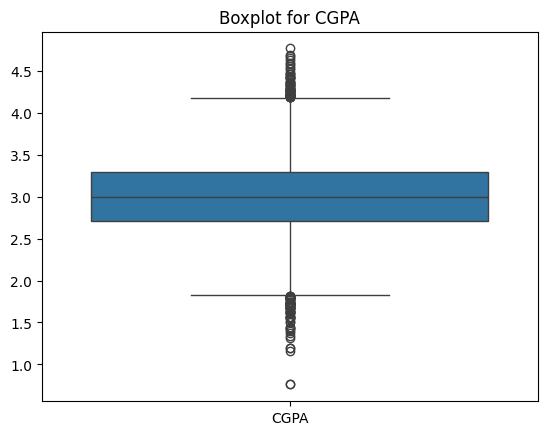

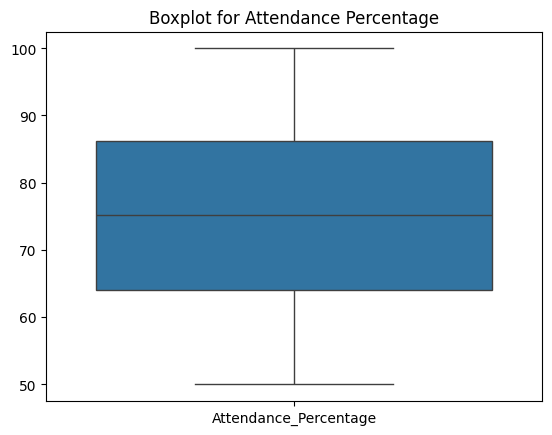

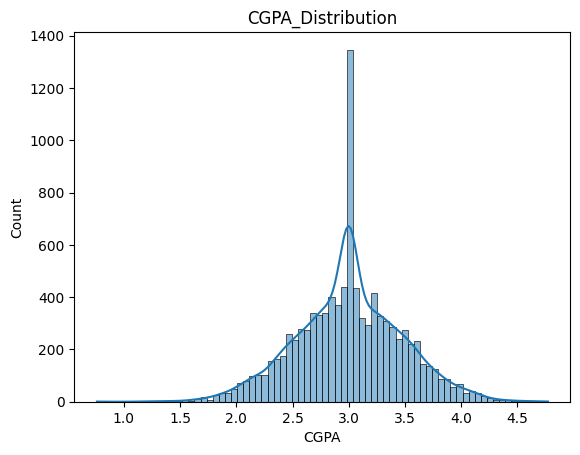

In [18]:
# Boxplots for detecting outliers
sns.boxplot(data=df[['Age']])
plt.title('Boxplot for Age')
plt.show()

sns.boxplot(data=df[['CGPA']])
plt.title('Boxplot for CGPA')
plt.show()

sns.boxplot(data=df[['Attendance_Percentage']])
plt.title('Boxplot for Attendance Percentage')
plt.show()

# Analyzing the boxplot: Outliers detected only in CGPA, also anomalies (CGPA greater than 4)

# Histogram for CGPA
sns.histplot(df['CGPA'], kde=True)
plt.title('CGPA_Distribution')
plt.show()

# Handling Outliers

##Identifying CGPA Outliers Using Z-Score

In [19]:
# Analyzing the boxplot: Outliers detected only in CGPA, also anomalies (CGPA greater than 4)

# Calculate Z-Scores
mean_cgpa = df['CGPA'].mean()
std_cgpa = df['CGPA'].std()
df['CGPA_Z'] = (df['CGPA'] - mean_cgpa) / std_cgpa

# determine Outliers
threshold = 3 #99.7% data
outliers = df.loc[abs(df['CGPA_Z']) > threshold, ['CGPA', 'CGPA_Z']]

# print Outliers
print("Outliers Found in CGPA:")
print(outliers)

# Total outliers
total_outliers = len(outliers)
print("Total Outliers Found:", total_outliers)

Outliers Found in CGPA:
      CGPA    CGPA_Z
343   0.76 -4.745050
401   1.57 -3.029591
480   1.31 -3.580232
494   4.56  3.302784
642   1.51 -3.156662
746   4.43  3.027463
1747  1.55 -3.071948
1964  1.16 -3.897910
2486  4.46  3.090999
3465  4.43  3.027463
3534  1.38 -3.431982
3601  4.66  3.514569
3682  1.54 -3.093126
3758  1.43 -3.326090
3885  1.40 -3.389625
4183  1.34 -3.516696
4769  4.49  3.154534
5444  4.42  3.006285
5616  4.69  3.578104
5730  4.63  3.451033
5758  1.57 -3.029591
5885  4.46  3.090999
5922  4.54  3.260427
6101  1.57 -3.029591
6315  1.20 -3.813196
6344  1.44 -3.304911
6679  4.60  3.387498
6763  4.59  3.366319
7323  4.43  3.027463
7444  4.43  3.027463
7478  4.47  3.112177
7720  4.77  3.747532
7722  0.77 -4.723871
7759  1.42 -3.347268
8390  1.45 -3.283733
8602  1.57 -3.029591
9041  4.68  3.556926
9175  4.53  3.239248
9493  1.51 -3.156662
9509  1.19 -3.834374
Total Outliers Found: 40


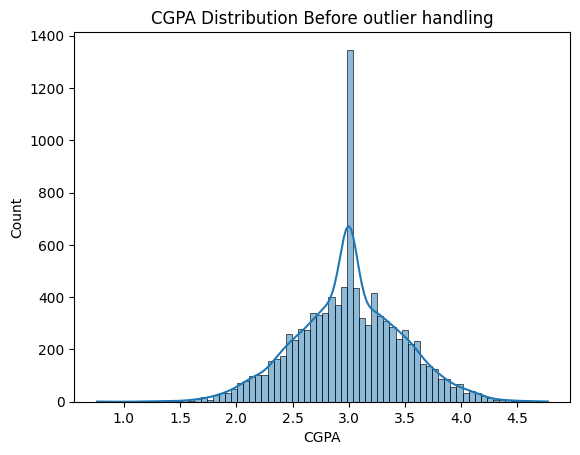

In [20]:
# Histogram for CGPA before handling outliers
sns.histplot(df['CGPA'],kde=True) #Kernal Density Estimation
plt.title('CGPA Distribution Before outlier handling')
plt.show()

##Handling CGPA Outliers Using Capping Method

Outliers capped successfully.


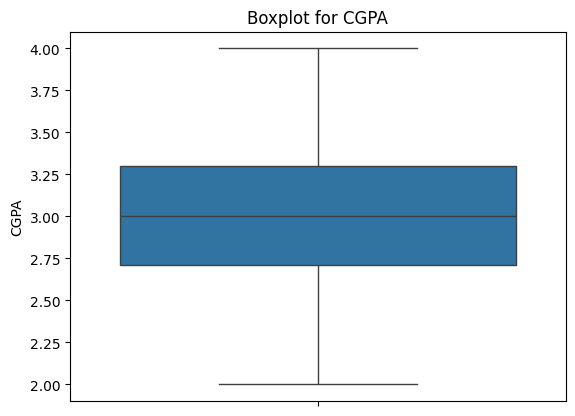

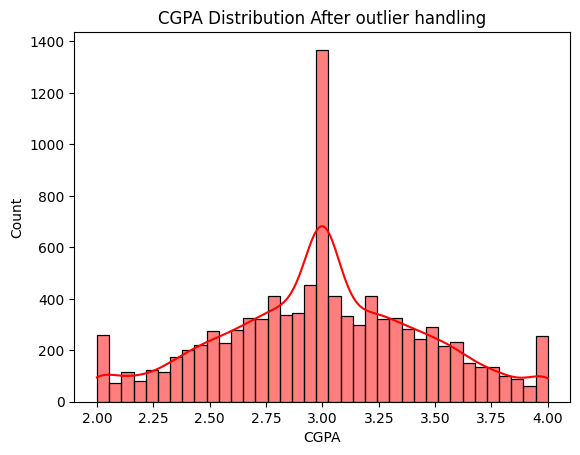

In [21]:
# limit for CGPA
lower_limit = 2
upper_limit = 4

# Capping CGPA Outliers to Handle Extremes
df['CGPA'] = np.where(df['CGPA'] < lower_limit, lower_limit,np.where(df['CGPA'] > upper_limit, upper_limit, df['CGPA']))
# Replacing the outlier values with lower limit & upper limit
print("Outliers capped successfully.")

#Boxplot after handling outliers
sns.boxplot(df['CGPA'])
plt.title('Boxplot for CGPA')
plt.show()

# Histogram for CGPA after handling outliers
sns.histplot(df['CGPA'],color='red', kde=True)
plt.title('CGPA Distribution After outlier handling')
plt.show()

# Feature Engineering

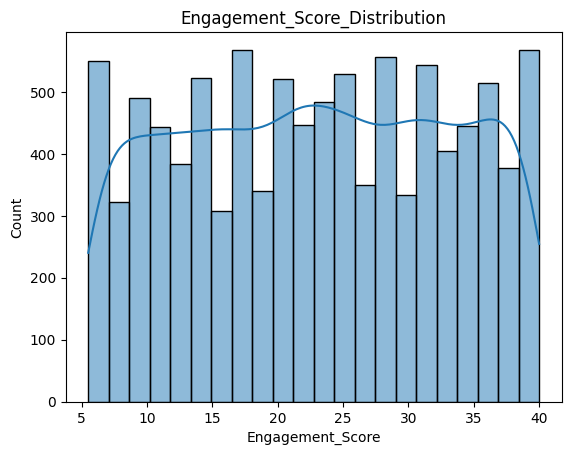

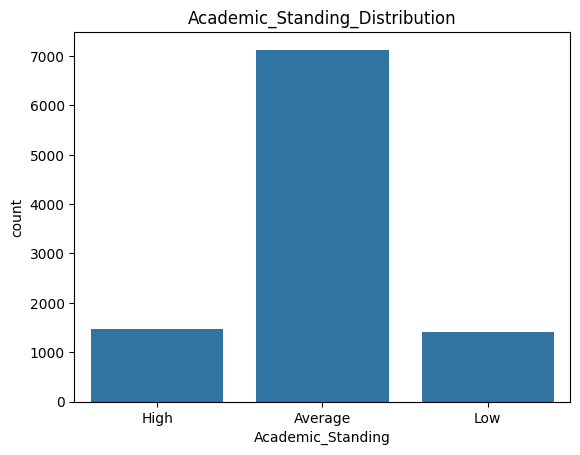

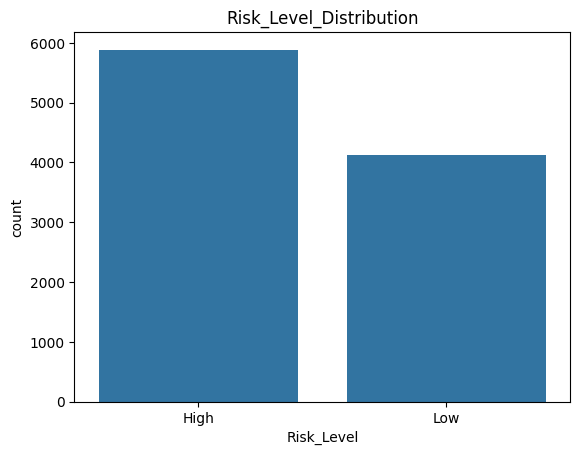

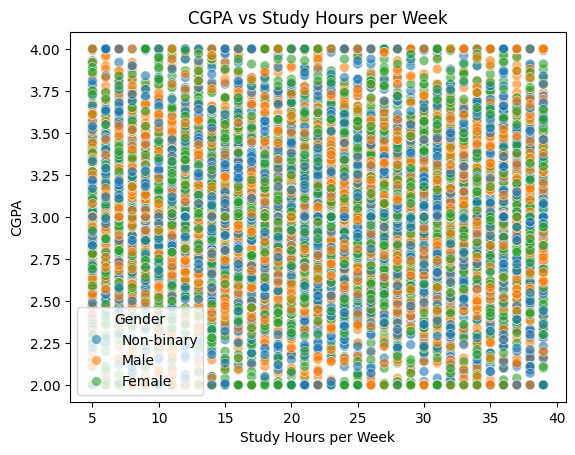

In [22]:
# Create Engagement Score
df['Engagement_Score'] = df['Study_Hours_per_Week'] + (df['Attendance_Percentage'] / 100)

# Create Academic Standing
def academic_standing(cgpa):
    if cgpa < 2.5:
        return 'Low'
    elif 2.5 <= cgpa < 3.5:
        return 'Average'
    else:
        return 'High'

df['Academic_Standing'] = df['CGPA'].apply(academic_standing)

# Create Risk Level based on conditions
def risk_level(row):
    if row['Attendance_Percentage'] < 60 or row['Part_Time_Job'] == 'Yes' or row['Satisfaction_Level'] == 'Low':
        return 'High'
    return 'Low'

df['Risk_Level'] = df.apply(risk_level, axis=1)

# Visualize the new features
# Engagement Score
sns.histplot(df['Engagement_Score'], kde=True)
plt.title('Engagement_Score_Distribution')
plt.show()

# Academic Standing
sns.countplot(data=df, x='Academic_Standing')
plt.title('Academic_Standing_Distribution')
plt.show()

# Risk Level
sns.countplot(data=df, x='Risk_Level')
plt.title('Risk_Level_Distribution')
plt.show()

# Scatter plot between CGPA and Study Hours per Week
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='CGPA', hue='Gender', alpha=0.6, s=50)
plt.title('CGPA vs Study Hours per Week')
plt.xlabel('Study Hours per Week')
plt.ylabel('CGPA')
plt.show()


# Advanceed Data Manipulation

##Average CGPA by Department and Year of Study


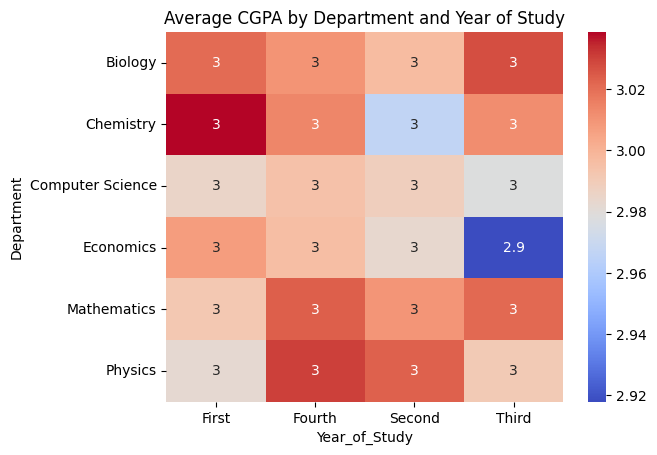

Year_of_Study,First,Fourth,Second,Third
Department,,,,
Biology,3.020854,3.009971,2.997017,3.027393
Chemistry,3.038613,3.013921,2.966880,3.012123
Computer Science,2.985341,2.994489,2.988519,2.978034
Economics,3.007265,2.996083,2.983097,2.917941
Mathematics,2.991895,3.023529,3.009554,3.021642
Physics,2.982453,3.030227,3.023525,2.990770


In [23]:
# Pivot table to summarize average CGPA by Department and Year of Study
pivot_table = df.pivot_table(values='CGPA', index='Department', columns='Year_of_Study', aggfunc='mean')

# Visualize the pivot table as a heatmap
sns.heatmap(pivot_table, annot=True, cmap='coolwarm')
plt.title('Average CGPA by Department and Year of Study')
plt.show()

pivot_table
# Chemistry(2nd) & Economics(3rd) indicates dip in performance


##Analyzing Engagement Score Across Departments and Genders

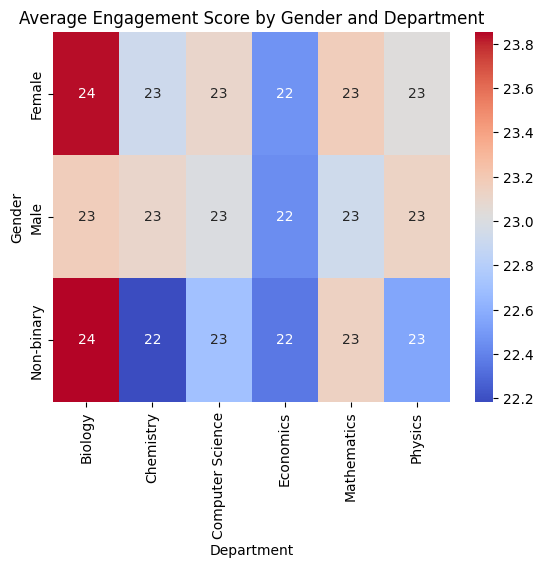

Department,Biology,Chemistry,Computer Science,Economics,Mathematics,Physics
Gender,,,,,,
Female,23.836038,22.926195,23.098008,22.470687,23.167581,23.027722
Male,23.168436,23.098165,23.005784,22.439586,22.933472,23.124283
Non-binary,23.853535,22.185132,22.705508,22.358526,23.140704,22.556365


In [24]:
# Groupby analysis of Engagement Score by Gender and Department
engagement_by_gender_dept = df.groupby(['Gender', 'Department'])['Engagement_Score'].mean().unstack()

# Visualize the Engagement Score using a heatmap
sns.heatmap(engagement_by_gender_dept, annot=True, cmap='coolwarm')
plt.title('Average Engagement Score by Gender and Department')
plt.show()

engagement_by_gender_dept


# Create Risk Level based on conditions and Family Income

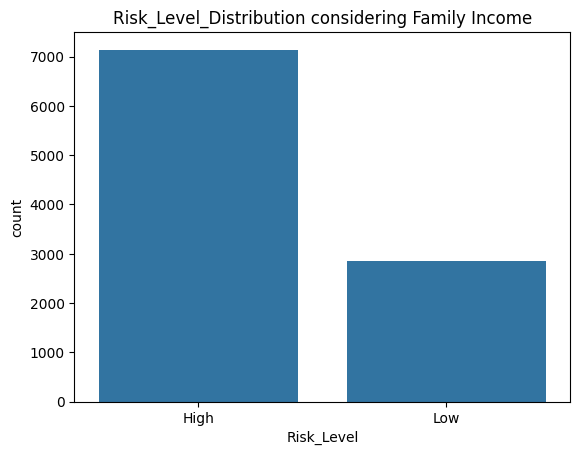

In [25]:
# Create Risk Level based on conditions and Family Income
def risk_level(row):
    if row['Attendance_Percentage'] < 60 or row['Part_Time_Job'] == 'Yes' or row['Family_Income'] == 'Low':
        return 'High'
    return 'Low'

df['Risk_Level'] = df.apply(risk_level, axis=1)

# Risk Level
sns.countplot(data=df, x='Risk_Level')
plt.title('Risk_Level_Distribution considering Family Income')
plt.show()

In [26]:
df.head()

,Student_ID,Age,Gender,Department,Year_of_Study,CGPA,Attendance_Percentage,Study_Hours_per_Week,Extracurricular_Activities,Part_Time_Job,Satisfaction_Level,Scholarship,Parental_Education_Level,Internet_Access,Family_Income,CGPA_Z,Engagement_Score,Academic_Standing,Risk_Level
0,S0001,24,Non-binary,Biology,Second,3.78,86.13,28,Yes,Yes,Neutral,Yes,PhD,Yes,Low,1.650860,28.8613,High,High
1,S0002,21,Non-binary,Physics,Third,2.69,57.24,11,No,No,Very Satisfied,No,PhD,No,Medium,-0.657598,11.5724,Average,High
2,S0003,28,Male,Economics,Third,2.85,71.93,19,Yes,Yes,Very Dissatisfied,No,Bachelor's,No,Medium,-0.318741,19.7193,Average,High
3,S0004,25,Male,Chemistry,Fourth,2.91,77.15,29,Yes,No,Very Satisfied,No,Bachelor's,No,Medium,-0.191670,29.7715,Average,Low
4,S0005,22,Female,Biology,Fourth,2.35,85.11,21,Yes,No,Dissatisfied,Yes,High School,No,High,-1.377667,21.8511,Low,Low


In [27]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

# 1. Encoding 'Age' (Min-MaxScaler Scaling)
scaler_age = MinMaxScaler()
df['Age'] = scaler_age.fit_transform(df[['Age']])

# 2. Encoding 'Gender' (Label Encoding)
ohe_gender = LabelEncoder()
df['Gender'] = ohe_gender.fit_transform(df['Gender'])

# 3. Encoding 'Department' (Label Encoding)
le_department = LabelEncoder()
df['Department'] = le_department.fit_transform(df['Department'])

# 4. Encoding 'Year_of_Study' (Ordinal Encoding)
ordinal_mapping_year = ['First', 'Second', 'Third', 'Fourth']
oe_year = OrdinalEncoder(categories=[ordinal_mapping_year])
df['Year_of_Study'] = oe_year.fit_transform(df[['Year_of_Study']])

# 5. Encoding 'CGPA' (Min-Max Scaling)
scaler_cgpa = MinMaxScaler()
df['CGPA'] = scaler_cgpa.fit_transform(df[['CGPA']])

# 6. Encoding 'Attendance_Percentage' (Min-Max Scaling)
scaler_attendance = MinMaxScaler()
df['Attendance_Percentage'] = scaler_attendance.fit_transform(df[['Attendance_Percentage']])

# 7. Encoding 'Extracurricular_Activities' (Binary Encoding)
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].apply(lambda x: 1 if x == 'Yes' else 0)

# 8. Encoding 'Satisfaction_Level' (Ordinal Encoding)
ordinal_mapping_satisfaction = ['Very Dissatisfied', 'Dissatisfied', 'Neutral', 'Satisfied', 'Very Satisfied']
oe_satisfaction = OrdinalEncoder(categories=[ordinal_mapping_satisfaction])
df['Satisfaction_Level'] = oe_satisfaction.fit_transform(df[['Satisfaction_Level']])

# 9. Encoding 'Family_Income' (Label Encoding)
le_income = LabelEncoder()
df['Family_Income'] = le_income.fit_transform(df['Family_Income'])

# 10. Encoding 'Risk_Level' (Label Encoding)
le_risk = LabelEncoder()
df['Risk_Level'] = le_risk.fit_transform(df['Risk_Level'])

# 11. Encoding 'Academic_Standing' (Ordinal Encoding)
ordinal_mapping_standing = ['Low', 'Average', 'High']
oe_standing = OrdinalEncoder(categories=[ordinal_mapping_standing])
df['Academic_Standing'] = oe_standing.fit_transform(df[['Academic_Standing']])

# 12. Encoding 'Engagement_Score' (Min-Max Scaling)
scaler_Engagement_Score = MinMaxScaler()
df['Engagement_Score'] = scaler_Engagement_Score.fit_transform(df[['Engagement_Score']])

In [28]:
print(df.head())
print(df.info())

  Student_ID       Age  Gender  Department  Year_of_Study   CGPA  \
0      S0001  0.545455       2           0            1.0  0.890   
1      S0002  0.272727       2           5            2.0  0.345   
2      S0003  0.909091       1           3            2.0  0.425   
3      S0004  0.636364       1           1            3.0  0.455   
4      S0005  0.363636       0           0            3.0  0.175   

   Attendance_Percentage  Study_Hours_per_Week  Extracurricular_Activities  \
0               0.722745                    28                           1   
1               0.144829                    11                           0   
2               0.438688                    19                           1   
3               0.543109                    29                           1   
4               0.702340                    21                           1   

  Part_Time_Job  Satisfaction_Level Scholarship Parental_Education_Level  \
0           Yes                 2.0         Ye

In [29]:
columns_to_drop = ['Student_ID', 'Scholarship', 'Parental_Education_Level', 'Internet_Access', 'Part_Time_Job', 'CGPA_Z']
df = df.drop(columns=columns_to_drop)

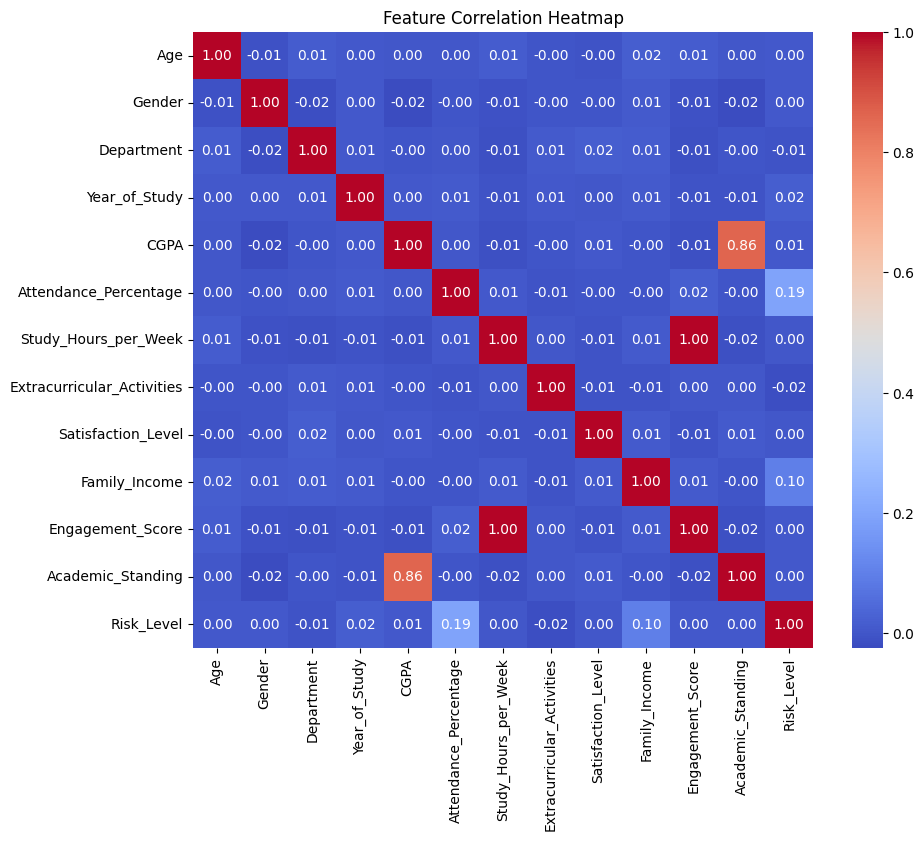

In [30]:
# Compute correlation matrix
correlation_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [31]:
columns_to_drop = ['Age', 'Gender', 'Department', 'Satisfaction_Level', 'Study_Hours_per_Week', 'Extracurricular_Activities', 'Engagement_Score',
                   'Department', 'Year_of_Study']
df = df.drop(columns=columns_to_drop)

In [32]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CGPA                   10000 non-null  float64
 1   Attendance_Percentage  10000 non-null  float64
 2   Family_Income          10000 non-null  int64  
 3   Academic_Standing      10000 non-null  float64
 4   Risk_Level             10000 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 390.8 KB
None


In [33]:
!pip install scikit-learn xgboost imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from statsmodels.formula.api import ols

In [34]:
# Define features and target
y = df['Academic_Standing']
X = df.drop(columns=['Academic_Standing'])

# Map labels to start from 0
y_mapped = y - y.min()

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.3, random_state=42)

# Initialize the scaler
scaler = MinMaxScaler()

# Standardize the data for models that need it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression with increased iterations
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# Support Vector Machine (SVM)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# XGBoost with early stopping and proper configuration for multi-class classification
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_estimators=500,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,
    reg_lambda=1,
    early_stopping_rounds=10
)

# Perform stratified k-fold cross-validation with early stopping
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in cv.split(X_train_scaled, y_train):
    X_train_cv, X_val_cv = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_train_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb_model.fit(X_train_cv, y_train_cv, eval_set=[(X_val_cv, y_val_cv)], verbose=False)
    y_pred_cv = xgb_model.predict(X_val_cv)
    cv_scores.append(accuracy_score(y_val_cv, y_pred_cv))


# Fit the XGBoost model with early stopping on the full training set
xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_test_scaled, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test_scaled)



# Evaluation function to print the metrics
def evaluate_model(y_test, y_pred, model_name):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    print(f"Model: {model_name}")
    print(confusion_matrix(y_test, y_pred))
    print(f"{model_name} Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}\n")

# Evaluating all models
evaluate_model(y_test, y_pred_lr, 'Logistic Regression')
evaluate_model(y_test, y_pred_rf, 'Random Forest')
evaluate_model(y_test, y_pred_svm, 'SVM')
evaluate_model(y_test, y_pred_xgb, 'XGBoost')

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:38:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:38:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:38:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:39:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [19:39:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Model: Logistic Regression
[[ 389   50    0]
 [   0 2118    0]
 [   0   34  409]]
Logistic Regression Performance:
Accuracy: 0.9720
Precision: 0.9873
Recall: 0.9365
F1-Score: 0.9601

Model: Random Forest
[[ 439    0    0]
 [   0 2118    0]
 [   0    0  443]]
Random Forest Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Model: SVM
[[ 419   20    0]
 [   0 2118    0]
 [   0   13  430]]
SVM Performance:
Accuracy: 0.9890
Precision: 0.9949
Recall: 0.9750
F1-Score: 0.9847

Model: XGBoost
[[ 439    0    0]
 [   0 2118    0]
 [   0    0  443]]
XGBoost Performance:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000



In [42]:
import shap

# Ensure the SVM model is trained with probability=True
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train_scaled, y_train)

# SHAP analysis for SVM
explainer_svm = shap.KernelExplainer(svm_model.predict_proba, X_train_scaled[:10])
shap_values_svm = explainer_svm.shap_values(X_train_scaled)

# Visualize the first prediction's explanation for SVM
shap.initjs()
shap.force_plot(explainer_svm.expected_value[0], shap_values_svm[0,:,0], X_train.iloc[0,:])

  0%|          | 0/7000 [00:00<?, ?it/s]

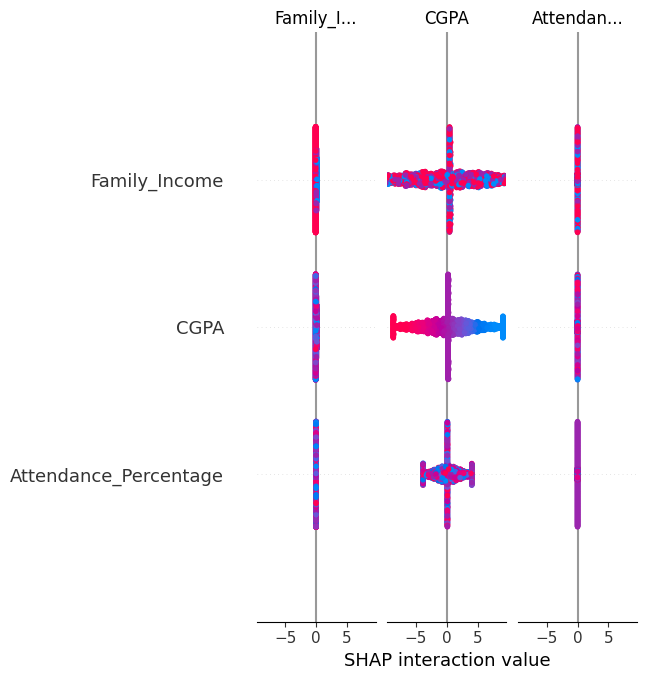

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import shap

# Define features and target
y = df['Academic_Standing']
X = df.drop(columns=['Academic_Standing'])

# Initialize the scaler
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)


# Support Vector Machine (SVM)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Compute SHAP values
explainer = shap.Explainer(svm_model, X_train)
shap_values = explainer(X_test)

# Visualizations
shap.summary_plot(shap_values, X_test, plot_type="dot", feature_names=X.columns)  # Summary bee-swarm plot